# 01 — Exploratory Data Analysis: Delhi Electricity Demand

This notebook explores the merged load + weather + holiday dataset before any modeling.
The goal of EDA here is specific, not decorative: every plot below answers a question
that directly affects which forecasting models make sense and how we should engineer
features later.

**Dataset:** hourly Delhi grid load (MW), Apr 2023 – Jan 2026, with temperature/humidity
and Indian holiday flags merged in.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 4)

df = pd.read_csv("../data/processed/load_weather_hourly.csv", index_col=0, parse_dates=True)
df.index.name = "timestamp"
print(df.shape)
df.head()

(15580, 5)


,load_MW,temperature_2m,relative_humidity_2m,is_holiday,holiday_name
timestamp,,,,,
2023-04-01 00:00:00,2171.167500,16.6,97.0,0,NaN
2023-04-01 01:00:00,2059.953333,16.0,98.0,0,NaN
2023-04-01 02:00:00,1994.826667,15.5,99.0,0,NaN
2023-04-01 03:00:00,1967.669167,15.2,99.0,0,NaN
2023-04-01 04:00:00,2043.052500,15.1,98.0,0,NaN


## 1. Basic sanity checks

Before looking at patterns, confirm the data is what we think it is: right date range,
reasonable value ranges, and how much is missing.


In [8]:
print("Date range:", df.index.min(), "to", df.index.max())
print("\nMissing values per column:")
print(df.isna().sum())
print("\nLoad (MW) summary:")
df["load_MW"].describe()

Date range: 2023-04-01 00:00:00 to 2025-01-09 03:00:00

Missing values per column:
load_MW                   171
temperature_2m            196
relative_humidity_2m      196
is_holiday                  0
holiday_name            14788
dtype: int64

Load (MW) summary:


count    15409.000000
mean      4314.694518
std       1324.257495
min       1540.942500
25%       3391.601667
50%       4254.984167
75%       5291.695000
max       8565.135000
Name: load_MW, dtype: float64

**What to look for:** if `load_MW` has implausible values (negative, or a max that's
10x the median), that's a data quality issue to fix before doing anything else — no amount
of clever modeling fixes bad inputs.


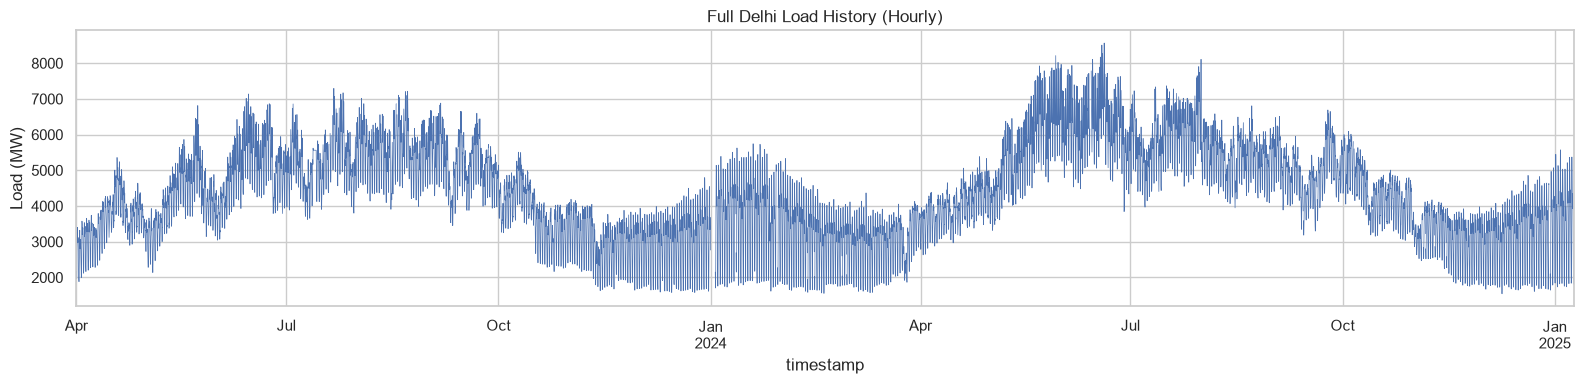

In [9]:
fig, ax = plt.subplots(figsize=(16, 4))
df["load_MW"].plot(ax=ax, linewidth=0.5)
ax.set_title("Full Delhi Load History (Hourly)")
ax.set_ylabel("Load (MW)")
plt.tight_layout()
plt.show()

In [10]:
print("Index dtype:", df.index.dtype)
print("Index min/max:", df.index.min(), "/", df.index.max())
print("Is monotonic increasing:", df.index.is_monotonic_increasing)
print("Any June 2024 rows?", ((df.index >= "2024-06-01") & (df.index < "2024-06-08")).sum())
print(df.index[:5])

Index dtype: datetime64[us]
Index min/max: 2023-04-01 00:00:00 / 2025-01-09 03:00:00
Is monotonic increasing: True
Any June 2024 rows? 168
DatetimeIndex(['2023-04-01 00:00:00', '2023-04-01 01:00:00',
               '2023-04-01 02:00:00', '2023-04-01 03:00:00',
               '2023-04-01 04:00:00'],
              dtype='datetime64[us]', name='timestamp', freq=None)


## 2. Why this plot matters

At full-range zoom, individual days are invisible — but this view is still useful for
spotting **big-picture structure**: is there a clear summer/winter seasonal swing (there
should be — Delhi's AC load in summer is a major driver)? Are there any sudden multi-day
flat lines or spikes that suggest sensor/comms failures rather than real demand changes?
Flag anything suspicious now; you'll want to exclude those periods from training later
rather than let a model learn from a data glitch.


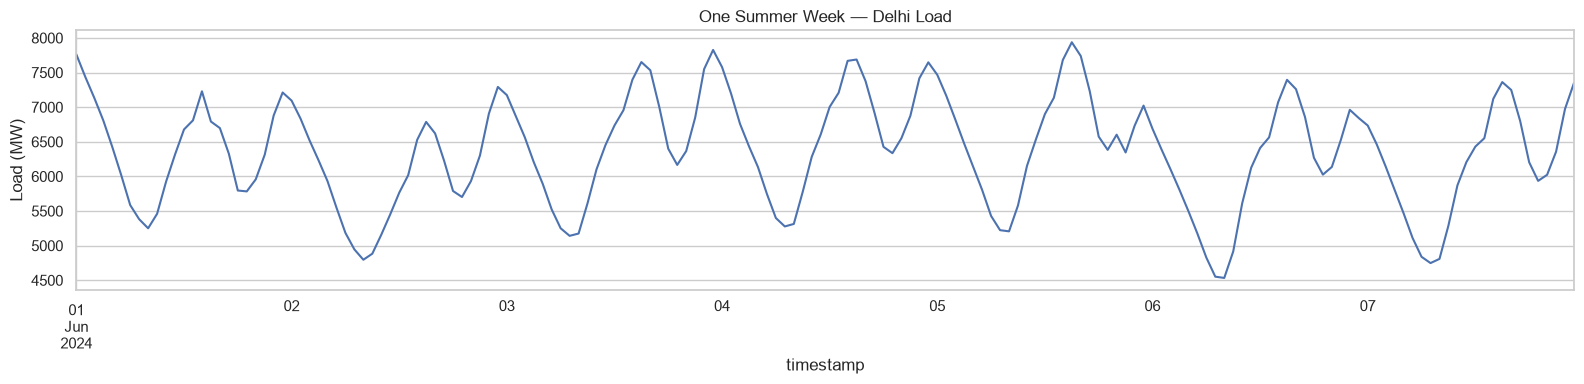

In [11]:
# Zoom into one week to see the daily/weekly rhythm clearly
week = df[(df.index >= "2024-06-01") & (df.index < "2024-06-08")]
fig, ax = plt.subplots(figsize=(16, 4))
week["load_MW"].plot(ax=ax)
ax.set_title("One Summer Week — Delhi Load")
ax.set_ylabel("Load (MW)")
plt.tight_layout()
plt.show()

**What to look for:** a clear daily cycle (low load overnight, peaks in morning and
evening) and a weekday-vs-weekend difference. If both are visible, that confirms daily and
weekly seasonality need to be explicit features (hour-of-day, day-of-week) for the ML
models, and explicit seasonal orders for SARIMA.


## 3. Seasonal decomposition

`seasonal_decompose` splits the series into three additive (or multiplicative) parts:

- **Trend** — the slow-moving underlying level (is demand growing year over year?)
- **Seasonal** — the repeating pattern at a fixed period (we'll check daily = 24 hours)
- **Residual** — whatever's left after removing trend and seasonality (ideally close to noise)

This isn't just a pretty plot — it's diagnostic. If the residual still has obvious
structure, it means one seasonal period isn't enough to explain the data (which is exactly
the case here: load has *both* a daily AND a weekly AND an annual cycle stacked on top of
each other, and a single decomposition can only pull out one at a time).


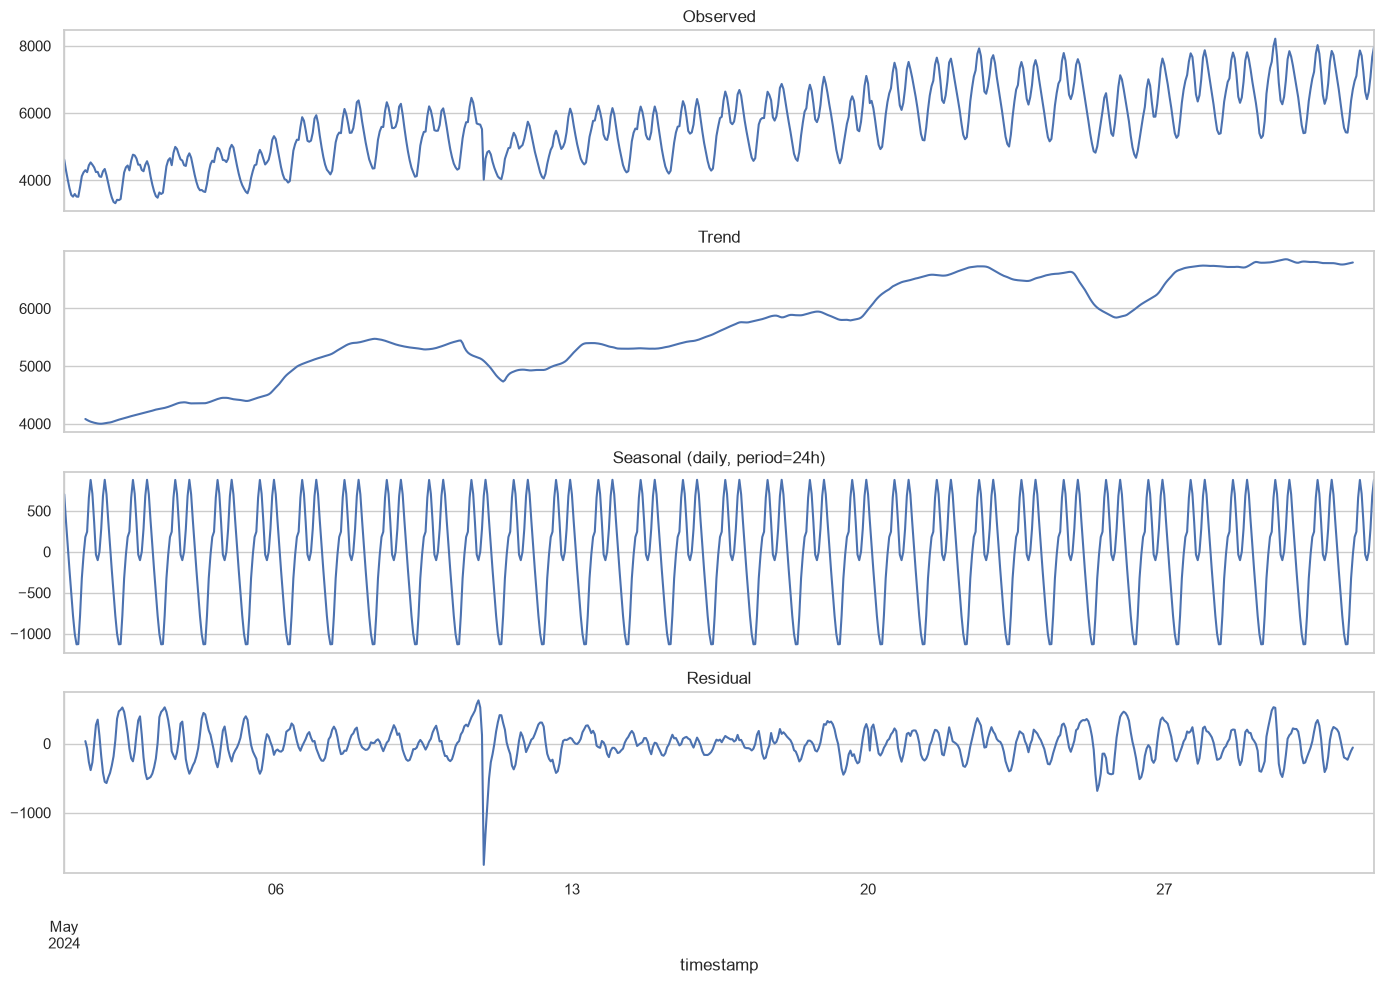

In [12]:
# Decompose with a daily (24-hour) period on a representative month to keep it readable
sample = df.loc["2024-05-01":"2024-05-31", "load_MW"]
decomp = seasonal_decompose(sample, model="additive", period=24)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp.observed.plot(ax=axes[0], title="Observed")
decomp.trend.plot(ax=axes[1], title="Trend")
decomp.seasonal.plot(ax=axes[2], title="Seasonal (daily, period=24h)")
decomp.resid.plot(ax=axes[3], title="Residual")
plt.tight_layout()
plt.show()

**What to look for:** a clean, repeating sawtooth in the seasonal panel confirms the
daily cycle is strong and consistent — good news, it's an easy signal for models to pick
up. If the residual panel still shows visible rises/dips at a slower rhythm, that's the
weekly and annual seasonality leaking through, which we'll capture separately with
calendar features rather than try to force into one decomposition.


## 4. Autocorrelation (ACF) and Partial Autocorrelation (PACF)

These answer: **"how much does the load right now depend on the load N hours/days ago?"**

- **ACF** shows the raw correlation between the series and its own lagged values.
- **PACF** shows the correlation at each lag *after removing* the effect of all shorter
  lags — i.e. it isolates the direct relationship at that specific lag.

Why this matters practically: the lags where ACF/PACF spike are exactly the lag features
worth engineering for the ML models (e.g. `load_lag_24h`, `load_lag_168h` for the same
hour yesterday / same hour last week), and they determine the (p, q) orders if we fit
SARIMA properly instead of guessing.


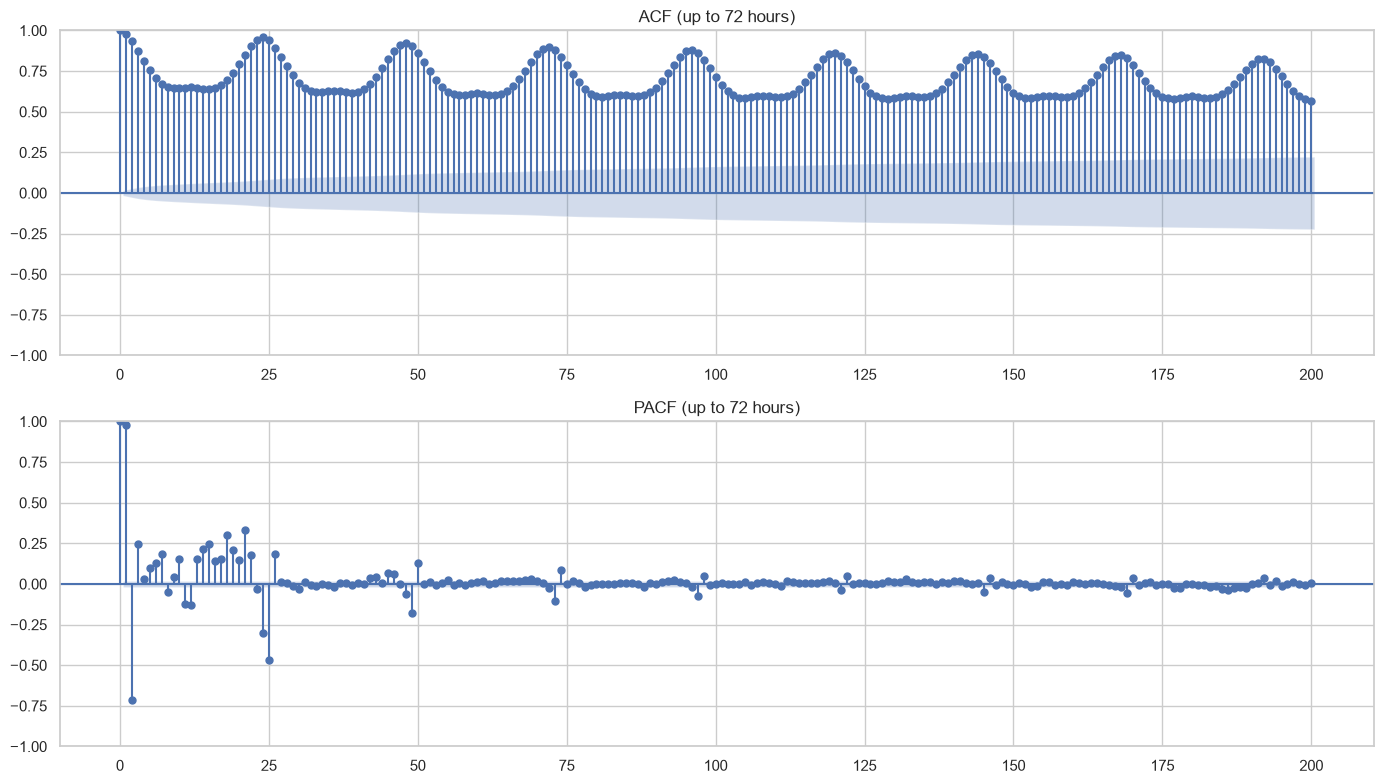

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(df["load_MW"].dropna(), lags=200, ax=axes[0])
axes[0].set_title("ACF (up to 72 hours)")
plot_pacf(df["load_MW"].dropna(), lags=200, ax=axes[1], method="ywm")
axes[1].set_title("PACF (up to 72 hours)")
plt.tight_layout()
plt.show()

**What to look for:** expect a strong spike at lag 24 (yesterday, same hour) and
likely at lag 168 (same hour, one week ago) once you extend the lag range further — try
changing `lags=72` to `lags=200` to check the weekly lag directly.


## 5. Stationarity check (Augmented Dickey-Fuller test)

Most classical models (ARIMA family) assume the series is **stationary** — its statistical
properties (mean, variance) don't change over time. Electricity load usually isn't
stationary on its own (there's a trend, and strong seasonality), so this test tells us
whether we need to difference the series before fitting SARIMA, and by how much.

The ADF test's null hypothesis is "the series is non-stationary." A small p-value
(conventionally < 0.05) lets us reject that and treat it as stationary.


In [14]:
result = adfuller(df["load_MW"].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.6f}")
print("Stationary" if result[1] < 0.05 else "Non-stationary — differencing needed for SARIMA")

ADF Statistic: -3.3278
p-value: 0.013679
Stationary


## 6. Weather relationship

Delhi's demand is expected to be strongly driven by temperature (AC load in summer,
heating load — smaller effect — in winter). This plot checks that assumption directly
rather than assuming it.


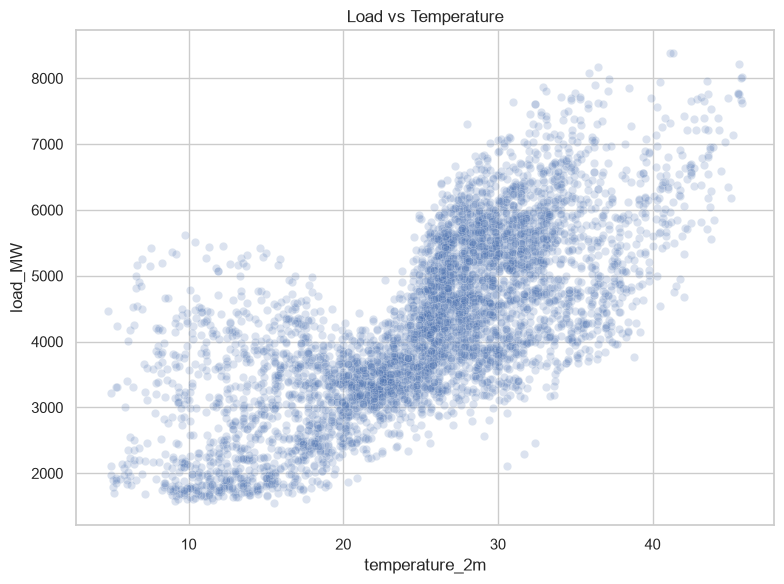

Correlation: 0.72


In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
sample_df = df.sample(min(5000, len(df)), random_state=42)  # sample for a readable scatter
sns.scatterplot(data=sample_df, x="temperature_2m", y="load_MW", alpha=0.2, ax=ax)
ax.set_title("Load vs Temperature")
plt.tight_layout()
plt.show()

print("Correlation:", df["temperature_2m"].corr(df["load_MW"]).round(3))

**What to look for:** if the relationship looks U-shaped or J-shaped rather than a
straight line (load high at both very hot AND somewhat cold temperatures, lower in mild
weather), a plain linear correlation coefficient will *understate* how important
temperature actually is — this is common for electricity demand and is a good thing to
call out explicitly in the report, since it justifies using tree-based models (which
handle non-linear relationships natively) over a plain linear model.


## 7. Holiday effect

Do holidays/festivals actually shift demand? This compares average hourly load on holiday
vs non-holiday days.


is_holiday
0    4331.313436
1    4006.749539
Name: load_MW, dtype: float64


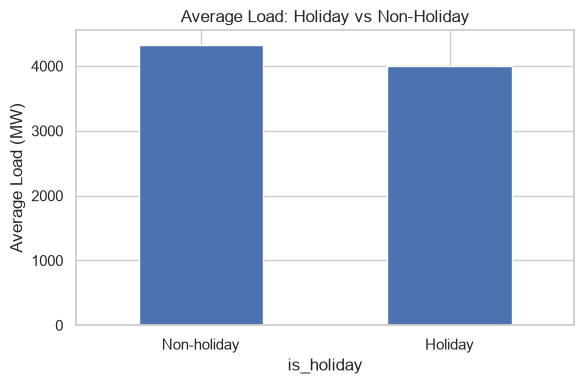

In [16]:
holiday_avg = df.groupby("is_holiday")["load_MW"].mean()
print(holiday_avg)

fig, ax = plt.subplots(figsize=(6, 4))
holiday_avg.plot(kind="bar", ax=ax)
ax.set_xticklabels(["Non-holiday", "Holiday"], rotation=0)
ax.set_ylabel("Average Load (MW)")
ax.set_title("Average Load: Holiday vs Non-Holiday")
plt.tight_layout()
plt.show()

## 8. Summary of findings

- The ADF test show that the data is stationary, which means we likely won't need heavy first-order differencing for SARIMA (d=0 is probably fine),
  though the strong daily/weekly seasonality still needs a seasonal order regardless of the plain stationarity test
- ACF shows dominant daily seasonality (peaks at every 24h multiple), no distinct additional spike at the weekly lag (168h) beyond the general daily pattern;
  suggesting day-of-week effects are better captured via calendar encodings than a raw weekly lag.
- Temperature can be observed to be an important factor in the average load, seemingly linear and
  showing a sudden jump in load when the temperature reaches around mid-20s.
- The holiday comparison shows that, surprisingly, there is not a significant difference in the average loads on regular days vs holidays.
- There seems to be a gap in data around early-january 2024, to be noted.

## Next steps

Move to `02_baselines.ipynb` (or continue in `src/`) to implement naive, seasonal naive,
and SARIMA baselines using the lag structure and stationarity findings from this notebook.
